In [1]:
import numpy as np
import toast
import os
import healpy as hp
from astropy.io import fits

path_to_volume = "/shared_home/henachman/data/sim_outputs/simple_hr10arcmin_jitter/mapmaker"
path_to_file = os.path.join(path_to_volume, "mlmapmaker_sky_map.fits")
path_to_truth = "/shared_home/henachman/home/SO_PointingReqs/sim_sky_maps/PS_maps/sim_maps/hr_simple_map_10arcmin.fits"
hdul = fits.open(path_to_truth)
hdul.info()

# toast.vis.plot_wcs_maps(
#     mapfile=str(path_to_file),
#     format="png",
#     cmap="RdBu"
# )

toast.vis.plot_wcs_maps(
    mapfile=str(path_to_file),
    format="png",
    cmap="RdBu"
)

Filename: /shared_home/henachman/home/SO_PointingReqs/sim_sky_maps/PS_maps/sim_maps/hr_simple_map_10arcmin.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     22   49152R x 3C   [1024D, 1024D, 1024D]   


# Compare 2 maps

In [25]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.colors import LogNorm


maps_to_load = [
    "/shared_home/henachman/data/sim_outputs/simple_hr10arcmin/mapmaker/mlmapmaker_sky_map.fits",
    "/shared_home/henachman/data/sim_outputs/simple_hr10arcmin_jitter/mapmaker/mlmapmaker_sky_map.fits"
]

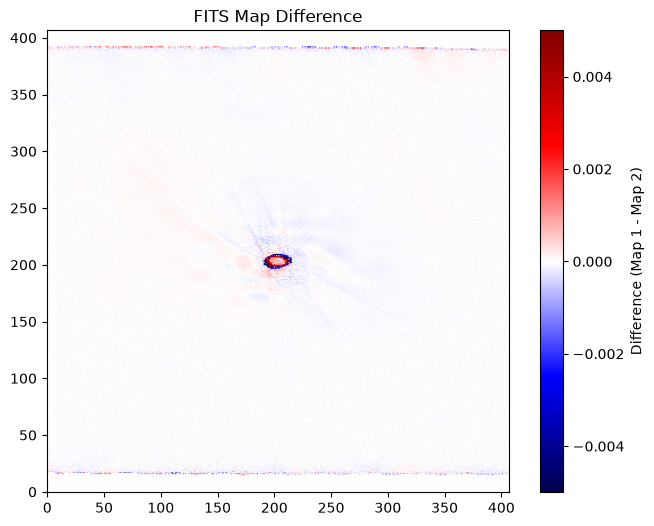

In [24]:
import matplotlib.pyplot as plt

# 1. Open the two FITS files
with fits.open(maps_to_load[0]) as hdul1, fits.open(maps_to_load[1]) as hdul2:
  data1 = hdul1[0].data
  data2 = hdul2[0].data

# 2. Compute the difference
diff_data = data1 - data2

# 3. Plot the difference map
plt.figure(figsize=(8, 6))
plt.imshow(diff_data[0], origin='lower', cmap='seismic', vmin=-5e-3, vmax=5e-3)
plt.colorbar(label='Difference (Map 1 - Map 2)')
plt.title('FITS Map Difference')
plt.show()


# View FilterBin map

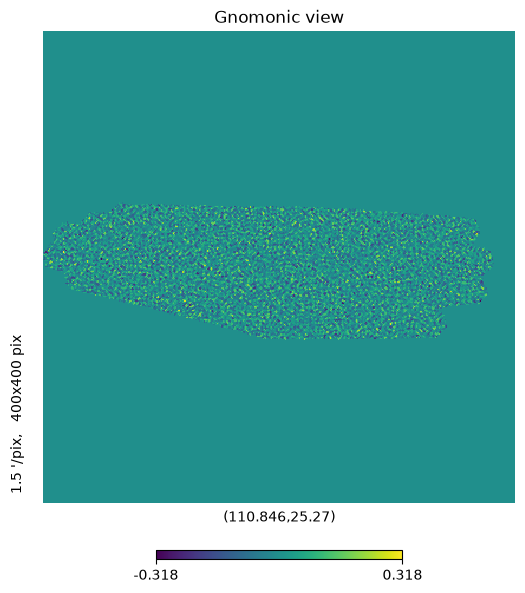

In [57]:
import healpy as hp

maps_to_load = [
    "/shared_home/henachman/data/sim_outputs/filterbin_f090_i1_Mars/filterbin_filtered_map.fits",
]

hit_maps = [
    "/shared_home/henachman/data/sim_outputs/filterbin_f090_i1_Mars/filterbin_filtered_hits.fits",
]

hpmap = hp.read_map(maps_to_load[0])
hphits = hp.read_map(hit_maps[0])
def gnomview_auto_center(data_map, hits_map, **kwargs):
    """
    Plots a healpy gnomview centered automatically on the mean position of hits.
    """
    # 1. Get the NSIDE from the map
    nside = hp.get_nside(hits_map)
    
    # 2. Find the pixel indices where hits are greater than zero
    # If using UNSEEN markers instead, change to: hits_map != hp.UNSEEN
    valid_pix = np.where(hits_map > 0)[0]
    
    if len(valid_pix) == 0:
        raise ValueError("The hits map contains no valid hit pixels.")
        
    # 3. Convert valid pixel indices to spherical coordinates (theta, phi)
    theta, phi = hp.pix2ang(nside, valid_pix)
    
    # 4. Convert spherical coordinates to Cartesian vectors to safely average them
    # (Averaging angles directly can break near the 0/360 boundary)
    vecs = hp.ang2vec(theta, phi)
    mean_vec = np.mean(vecs, axis=0)
    
    # 5. Convert the mean vector back to coordinates (Lon/Lat in degrees)
    mean_theta, mean_phi = hp.vec2ang(mean_vec)
    
    lon = np.degrees(mean_phi)
    lat = 90.0 - np.degrees(mean_theta)
    
    # 6. Pass the computed center to the rotation parameter 'rot'
    hp.gnomview(data_map, rot=[lon[0], lat[0], 0], **kwargs)

# --- Example Usage ---
gnomview_auto_center(hpmap, hphits, xsize=400, reso=1.5)
